<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 2.85e-04 | train loss 1.3113 acc 0.663 | val loss 0.6759 acc 0.713 *


[InceptionNet v3] Epoch   2/100 | LR: 2.85e-04 | train loss 1.1795 acc 0.691 | val loss 0.5999 acc 0.786 *


[InceptionNet v3] Epoch   3/100 | LR: 2.85e-04 | train loss 1.1018 acc 0.706 | val loss 0.4979 acc 0.833 *


[InceptionNet v3] Epoch   4/100 | LR: 2.85e-04 | train loss 1.0361 acc 0.726 | val loss 0.7100 acc 0.718


[InceptionNet v3] Epoch   5/100 | LR: 2.85e-04 | train loss 0.9596 acc 0.747 | val loss 0.6831 acc 0.707


...

[InceptionNet v3] Epoch  17/100 | LR: 2.85e-04 | train loss 0.2413 acc 0.935 | val loss 0.6492 acc 0.762


[InceptionNet v3] Epoch  18/100 | LR: 2.85e-04 | train loss 0.2574 acc 0.943 | val loss 0.8512 acc 0.751


[InceptionNet v3] Epoch  19/100 | LR: 2.85e-04 | train loss 0.2683 acc 0.943 | val loss 0.8849 acc 0.680


[InceptionNet v3] Epoch  20/100 | LR: 2.85e-04 | train loss 0.2178 acc 0.945 | val loss 0.8648 acc 0.783


[InceptionNet v3] Epoch  21/100 | LR: 2.85e-04 | train loss 0.1924 acc 0.958 | val loss 0.8050 acc 0.809

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 21.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4787)


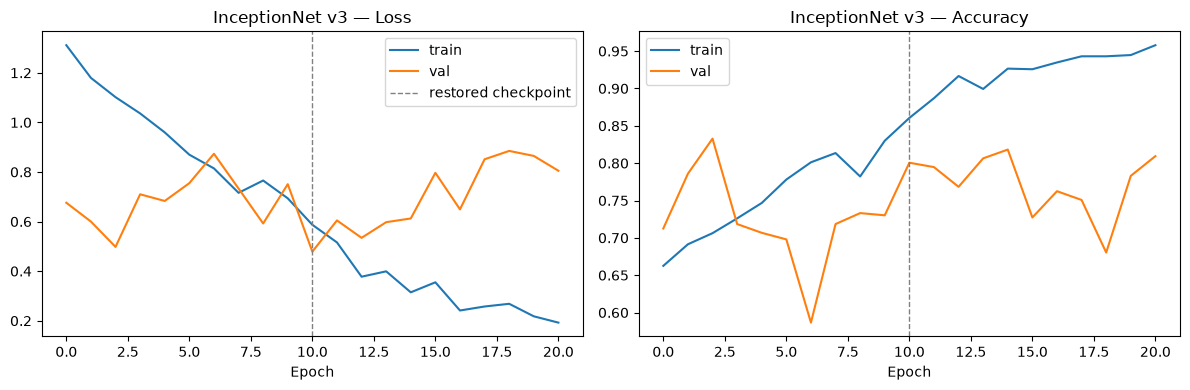

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.795


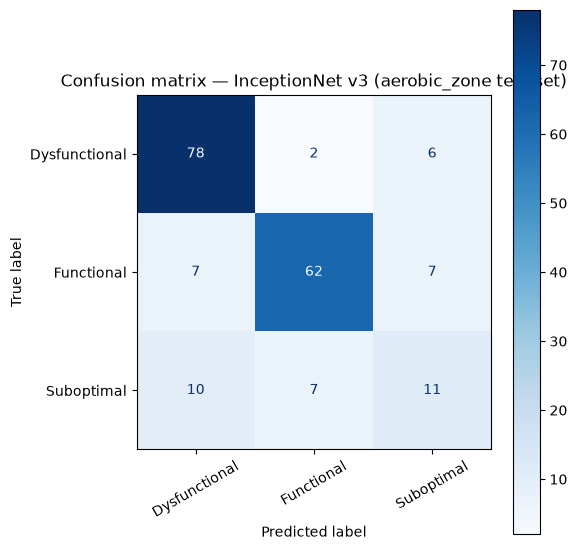

               precision    recall  f1-score   support

Dysfunctional      0.821     0.907     0.862        86
   Functional      0.873     0.816     0.844        76
   Suboptimal      0.458     0.393     0.423        28

     accuracy                          0.795       190
    macro avg      0.718     0.705     0.709       190
 weighted avg      0.788     0.795     0.790       190



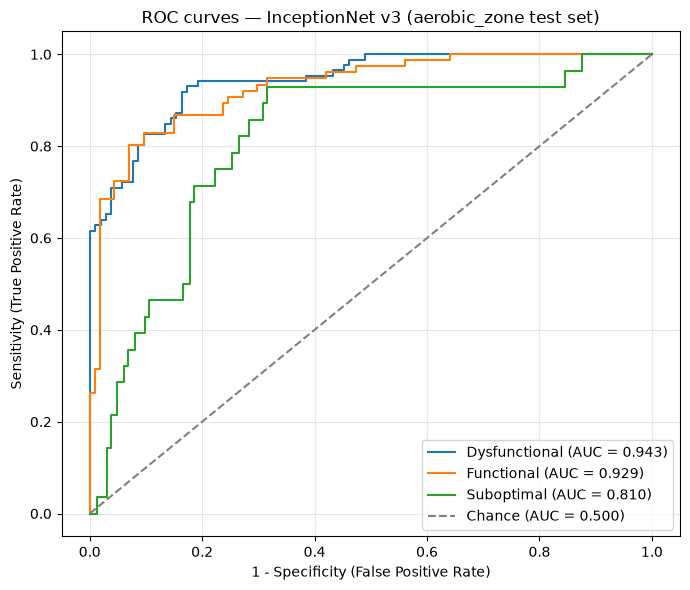

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.943
  Functional     : 0.929
  Suboptimal     : 0.810

Mean AUC (over 3/3 classes with test examples): 0.894


(np.float64(0.7947368421052632),
 {'Dysfunctional': 0.943313953488372,
  'Functional': 0.9286703601108033,
  'Suboptimal': 0.8104056437389772})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/aerobic_zone_noaug/results_aerobic_zone_inception_v3_stratified.pkl
Saved model weights to ../models/aerobic_zone_inception_v3_cnn.pt
